# Common Distributions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/common_distributions.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-21*

## Learning objectives

- See the shapes of five common probability distributions overlaid on a single plot: normal, uniform, log-normal, chi-square, and Student's t.
- Build a mental picture of which distributions are symmetric vs. skewed, bounded vs. unbounded, heavy-tailed vs. light-tailed.
- Get comfortable calling each distribution's PDF through `scipy.stats`.

Statistics is full of named distributions. This notebook gathers five of the most common ones and plots their probability density functions (PDFs) on the same axes so you can compare their shapes at a glance. Each one shows up later in the course in a different context — normal for the Central Limit Theorem, t for small-sample inference, chi-square and F for variance tests, log-normal as an example of a skewed distribution.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (8.0, 4.0)

Pick a representative set of parameters for each distribution. These are chosen so the PDFs all fit comfortably on the same axes — you can rerun the cells below with different values to see how the shapes change.

In [2]:
x = np.linspace(-7, 25, 1000)

# (name, scipy PDF call, plot color)
distributions = [
    ("Normal ($\\mu=0,\\ \\sigma=1$)", stats.norm.pdf(x, loc=0, scale=1), "blue"),
    ("Uniform ($a=-5,\\ b=5$)", stats.uniform.pdf(x, loc=-5, scale=10), "green"),
    (
        "Log-normal ($s=1,\\ \\mathrm{loc}=0,\\ \\mathrm{scale}=5$)",
        stats.lognorm.pdf(x, s=1, loc=0, scale=5),
        "purple",
    ),
    ("Chi-square ($df=2$)", stats.chi2.pdf(x, df=2), "orange"),
    ("Student's t ($df=3$)", stats.t.pdf(x, df=3), "red"),
]

Plot all five PDFs on the same axes. A few things to look for as you read the figure:

- The **normal** and **t** distributions are symmetric around zero; the t has heavier tails for small `df`.
- The **uniform** is flat over $[-5, 5]$ and zero outside.
- The **log-normal** and **chi-square** are right-skewed, bounded below at zero (or at `loc`).
- All PDFs integrate to 1, but their peak heights differ because they spread over different ranges.

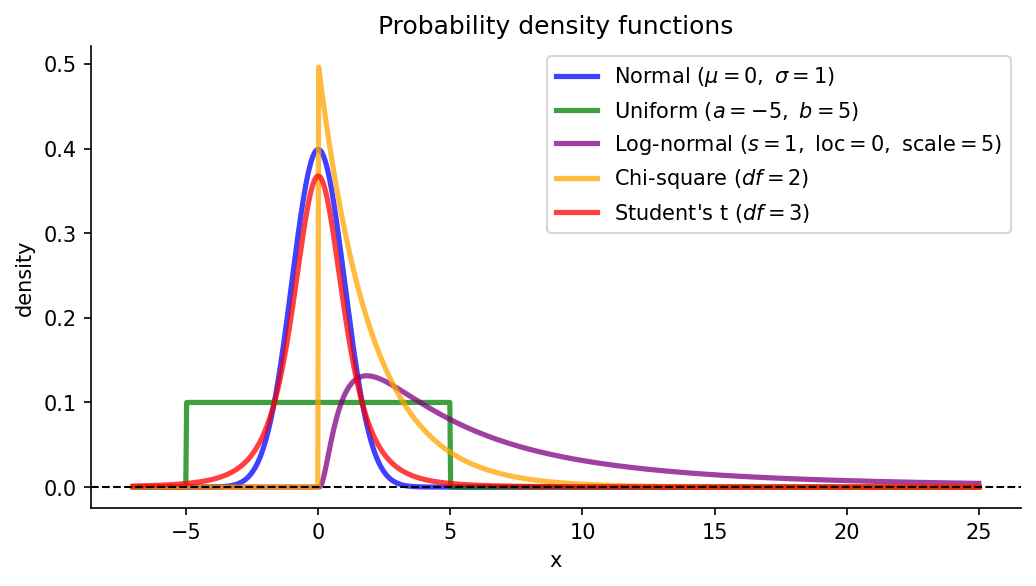

In [3]:
plt.figure()
for label, pdf, color in distributions:
    plt.plot(x, pdf, label=label, linewidth=2.5, alpha=0.75, color=color)

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.title("Probability density functions")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()

## Wrap-up

- Five common distributions, one plot — useful for building intuition about which one might describe a given dataset.
- `scipy.stats` exposes a `.pdf(x, ...)` for every named distribution. Once you know which family fits your data, you have its PDF, CDF, quantile function, and random-sampling routines for free.
- This notebook only shows the *shapes* — the actual tests built around each distribution (CLT for the normal, $\chi^2$ for variance, F for variance ratios, t for small-sample means) come up in their own notebooks.